In [ ]:
#add libraries for tabular and vector data and for plotting
import pandas as pd #tab
import geopandas as gpd #vector
import matplotlib.pyplot as plt #basic plotting
import seaborn as sns #advanced plotting
#mount google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#import counties
file = '/content/drive/My Drive/ESIIL2025MSU/Project Data/Colorado_County_Boundaries.geojson'
#define the variable
counties_gdf = gpd.read_file(file)
#select relevent columns
counties_gdf = counties_gdf[['COUNTY','geometry']]

In [ ]:
#import the national principal aquifer polygons
#import a folder
aquifers = gpd.read_file('/content/drive/My Drive/ESIIL2025MSU/Project Data/aquifers_us')
#remove null shapes
aquifers = aquifers[aquifers.AQ_CODE != 999]
#remove hawaii
aquifers = aquifers[aquifers.AQ_CODE != 608]
aquifers = aquifers[aquifers.AQ_CODE != 609]
#remove puerto rico and virgin islands
aquifers = aquifers[aquifers.AQ_CODE != 114]
aquifers = aquifers[aquifers.AQ_CODE != 419]
aquifers = aquifers[aquifers.AQ_CODE != 420]

#remove unnecessary columns
aquifers = aquifers.drop(['OBJECTID_1', 'ROCK_NAME', 'ROCK_TYPE', 'Shape_Leng', 'Shape_Area'], axis=1)
#show the data
aquifers.plot
aquifers

,AQ_NAME,AQ_CODE,geometry
2,Puget Sound aquifer system,112,"POLYGON ((-122.42146 47.27472, -122.41956 47.2..."
5,Upper Cretaceous aquifers,315,"POLYGON ((-106.73399 49.00137, -106.60622 49.0..."
6,Lower Tertiary aquifers,314,"POLYGON ((-106.57168 49.00181, -106.10797 49.0..."
7,Northern Rocky Mountains Intermontane Basins a...,105,"POLYGON ((-114.46533 49.00119, -114.38368 49.0..."
8,Lower Tertiary aquifers,314,"POLYGON ((-114.38368 49.00162, -114.30587 49.0..."
...,...,...,...
4078,Surficial aquifer system,111,"POLYGON ((-81.28715 25.69568, -81.29106 25.699..."
4079,Surficial aquifer system,111,"POLYGON ((-81.29293 25.68703, -81.29543 25.687..."
4080,Surficial aquifer system,111,"POLYGON ((-81.2048 25.54238, -81.2068 25.54243..."
4098,Biscayne aquifer,414,"POLYGON ((-81.06113 25.27399, -81.06509 25.275..."


(37.0, 41.0)

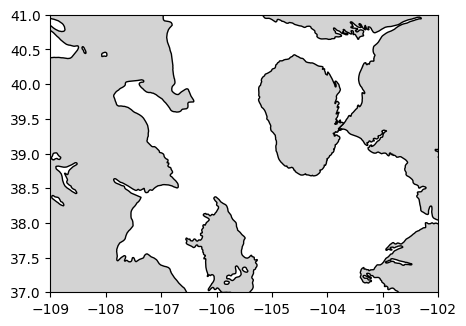

In [ ]:
#dissolve aquifers with the key field AQ_CODE
aquifers = aquifers.dissolve(by='AQ_CODE')
#show the data
aquifers.head()
#plot the data with ax.set_xlim(-109, -102) ax.set_ylim(37, 41)
fig, ax = plt.subplots(figsize=(5, 5))
aquifers.plot(ax=ax, color='lightgrey', edgecolor='black')
#set limits to focus on colorado
ax.set_xlim(-109, -102)
ax.set_ylim(37, 41)

In [ ]:
# import the near-surface alluvial aquifer polygons
alluvials = gpd.read_file('/content/drive/My Drive/ESIIL2025MSU/Project Data/CO_alluvials')
alluvials = alluvials.to_crs('EPSG:4269')
alluvials.plot(figsize=(5, 5), color='grey')
alluvials

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#import the groundwater station data
groundwater = pd.read_csv('/content/drive/My Drive/ESIIL2025MSU/Project Data/ALLWELL.csv', encoding='latin-1')
#convert groundwater.STATION to string and groundwater.72019 to float
groundwater['STATION'] = groundwater['STATION'].astype(str)
#remove trailing and leading spaces from groundwater[72019]
groundwater['72019'] = groundwater['72019'].astype(str).str.strip()
#remove all spaces from groundwater[72019]
groundwater['72019'] = groundwater['72019'].str.replace(' ', '', regex=False)
#convert groundwater.72019 to float
groundwater['72019'] = pd.to_numeric(groundwater['72019'], errors='coerce')
#rename WATER_YEAR to YEAR
groundwater = groundwater.rename(columns={'WATER_YEAR': 'YEAR'})
groundwater

,STATION,LATD,LATM,LATS,LONGD,LONGM,LONGS,ELEVATION,WELL_DEPTH,USAQ,LOCALAQ,YEAR,72019
0,372106105241701,37,21,6.2,105,24,18.6,7990.0,414.0,NaN,NaN,1981,157.526
1,372106105241701,37,21,6.2,105,24,18.6,7990.0,414.0,NaN,NaN,1982,162.154
2,372106105241701,37,21,6.2,105,24,18.6,7990.0,414.0,NaN,NaN,1983,164.027
3,372106105241701,37,21,6.2,105,24,18.6,7990.0,414.0,NaN,NaN,1984,161.377
4,372141105281101,37,21,41.6,105,28,13.6,7821.0,225.0,NaN,NaN,1981,25.039
...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,384240108000701,38,42,40.0,108,0,7.0,5190.0,22.7,COLORADO PLATEAUS,MANCOS SHALE,2016,9.275
214,401518102295701,40,15,18.0,102,29,57.0,3900.0,320.0,HIGH PLAINS,OGALLALA FORMATION,1993,128.242
215,374549105540201,37,45,49.0,105,54,2.0,7551.0,43.0,NaN,NaN,1983,7.492
216,374549105540201,37,45,49.0,105,54,2.0,7551.0,43.0,NaN,NaN,1984,7.085


In [ ]:
# The station data recorded location in Degrees, Minutes, Seconds
# Function to convert DMS to Decimal Degrees
def dms_to_dd(degrees, minutes, seconds):
    return degrees + minutes/60 + seconds/3600
# Convert latitude and longitude to decimal degrees
groundwater['LAT_DD'] = dms_to_dd(groundwater['LATD'], groundwater['LATM'], groundwater['LATS'])
# Note: Longitude in the dataset seems to be in the format of degrees, minutes, and seconds without a negative sign for Western Hemisphere.
# Assuming these are for the US, longitudes should be negative. Adjusting accordingly.
groundwater['LONG_DD'] = -dms_to_dd(groundwater['LONGD'], groundwater['LONGM'], groundwater['LONGS'])
# delete DMS columns
groundwater = groundwater.drop(['LATD', 'LATM', 'LATS', 'LONGD', 'LONGM', 'LONGS'], axis=1)
# delete unnecessary attributes, we'll spatial join later and well depth is confusing
# groundwater = groundwater.drop(['USAQ', 'LOCALAQ', 'WELL_DEPTH'], axis=1)
# Display the updated DataFrame with new columns
print(groundwater.dtypes)
groundwater

STATION        object
ELEVATION     float64
WELL_DEPTH    float64
USAQ           object
LOCALAQ        object
YEAR            int64
72019         float64
LAT_DD        float64
LONG_DD       float64
dtype: object


,STATION,ELEVATION,WELL_DEPTH,USAQ,LOCALAQ,YEAR,72019,LAT_DD,LONG_DD
0,372106105241701,7990.0,414.0,NaN,NaN,1981,157.526,37.351722,-105.405167
1,372106105241701,7990.0,414.0,NaN,NaN,1982,162.154,37.351722,-105.405167
2,372106105241701,7990.0,414.0,NaN,NaN,1983,164.027,37.351722,-105.405167
3,372106105241701,7990.0,414.0,NaN,NaN,1984,161.377,37.351722,-105.405167
4,372141105281101,7821.0,225.0,NaN,NaN,1981,25.039,37.361556,-105.470444
...,...,...,...,...,...,...,...,...,...
213,384240108000701,5190.0,22.7,COLORADO PLATEAUS,MANCOS SHALE,2016,9.275,38.711111,-108.001944
214,401518102295701,3900.0,320.0,HIGH PLAINS,OGALLALA FORMATION,1993,128.242,40.255000,-102.499167
215,374549105540201,7551.0,43.0,NaN,NaN,1983,7.492,37.763611,-105.900556
216,374549105540201,7551.0,43.0,NaN,NaN,1984,7.085,37.763611,-105.900556


In [ ]:
# water table elevation (62611) is equal to measured depth (72019) minus surface elevation
groundwater['62611'] = groundwater['ELEVATION'] - groundwater['72019']
groundwater

,STATION,ELEVATION,WELL_DEPTH,USAQ,LOCALAQ,YEAR,72019,LAT_DD,LONG_DD,62611
0,372106105241701,7990.0,414.0,NaN,NaN,1981,157.526,37.351722,-105.405167,7832.474
1,372106105241701,7990.0,414.0,NaN,NaN,1982,162.154,37.351722,-105.405167,7827.846
2,372106105241701,7990.0,414.0,NaN,NaN,1983,164.027,37.351722,-105.405167,7825.973
3,372106105241701,7990.0,414.0,NaN,NaN,1984,161.377,37.351722,-105.405167,7828.623
4,372141105281101,7821.0,225.0,NaN,NaN,1981,25.039,37.361556,-105.470444,7795.961
...,...,...,...,...,...,...,...,...,...,...
213,384240108000701,5190.0,22.7,COLORADO PLATEAUS,MANCOS SHALE,2016,9.275,38.711111,-108.001944,5180.725
214,401518102295701,3900.0,320.0,HIGH PLAINS,OGALLALA FORMATION,1993,128.242,40.255000,-102.499167,3771.758
215,374549105540201,7551.0,43.0,NaN,NaN,1983,7.492,37.763611,-105.900556,7543.508
216,374549105540201,7551.0,43.0,NaN,NaN,1984,7.085,37.763611,-105.900556,7543.915


,STATION,ELEVATION,WELL_DEPTH,USAQ,LOCALAQ,YEAR,72019,LAT_DD,LONG_DD,62611,geometry
0,372106105241701,7990.0,414.0,NaN,NaN,1981,157.526,37.351722,-105.405167,7832.474,POINT (-105.40517 37.35172)
1,372106105241701,7990.0,414.0,NaN,NaN,1982,162.154,37.351722,-105.405167,7827.846,POINT (-105.40517 37.35172)
2,372106105241701,7990.0,414.0,NaN,NaN,1983,164.027,37.351722,-105.405167,7825.973,POINT (-105.40517 37.35172)
3,372106105241701,7990.0,414.0,NaN,NaN,1984,161.377,37.351722,-105.405167,7828.623,POINT (-105.40517 37.35172)
4,372141105281101,7821.0,225.0,NaN,NaN,1981,25.039,37.361556,-105.470444,7795.961,POINT (-105.47044 37.36156)
...,...,...,...,...,...,...,...,...,...,...,...
213,384240108000701,5190.0,22.7,COLORADO PLATEAUS,MANCOS SHALE,2016,9.275,38.711111,-108.001944,5180.725,POINT (-108.00194 38.71111)
214,401518102295701,3900.0,320.0,HIGH PLAINS,OGALLALA FORMATION,1993,128.242,40.255000,-102.499167,3771.758,POINT (-102.49917 40.255)
215,374549105540201,7551.0,43.0,NaN,NaN,1983,7.492,37.763611,-105.900556,7543.508,POINT (-105.90056 37.76361)
216,374549105540201,7551.0,43.0,NaN,NaN,1984,7.085,37.763611,-105.900556,7543.915,POINT (-105.90056 37.76361)


<Axes: >

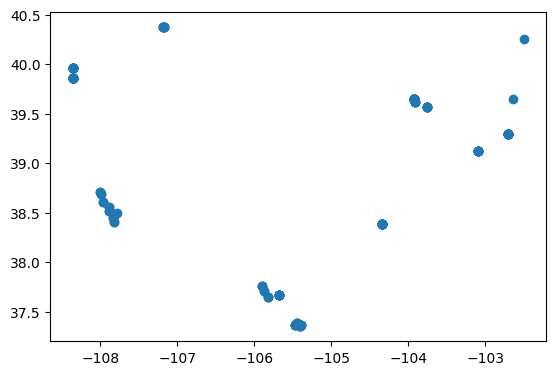

In [ ]:
# Convert groundwater DataFrame to a GeoDataFrame
groundwater_gdf = gpd.GeoDataFrame(
    groundwater,
    geometry=gpd.points_from_xy(groundwater['LONG_DD'], groundwater['LAT_DD']),
    crs="EPSG:4269" #us maps
)
display(groundwater_gdf)
groundwater_gdf.plot()

/tmp/ipython-input-70-3298608357.py:26: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  aquifer_patch = mpatches.Patch(color='lightgrey', label='Deep Geological Aquifer', edgecolor='black')


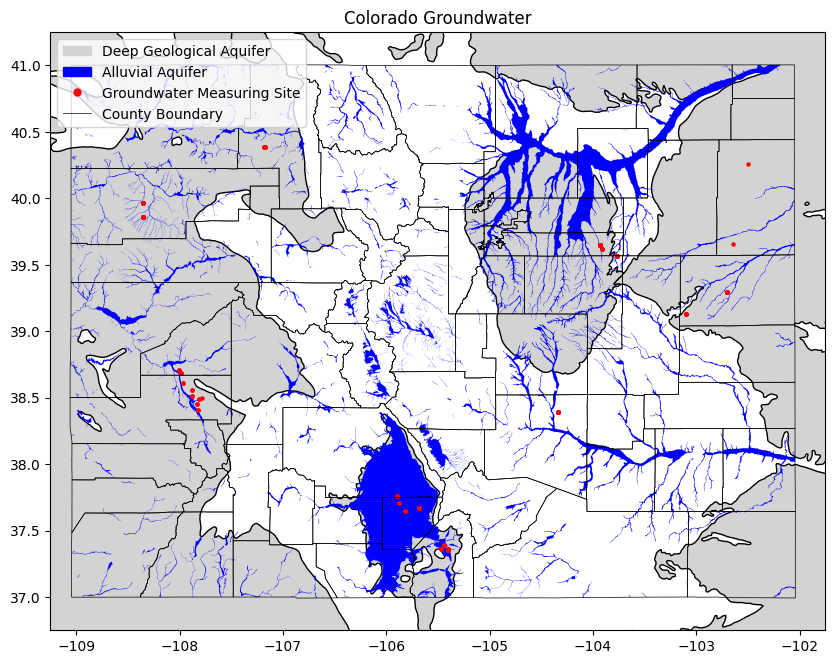

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

#project to common coordinate system crs epsg 4326
groundwater_gdf = groundwater_gdf.to_crs(epsg=4326)
alluvials = alluvials.to_crs(epsg=4326)
aquifers = aquifers.to_crs(epsg=4326)
counties_gdf = counties_gdf.to_crs(epsg=4326)
#create figure and set size
fig, ax = plt.subplots(figsize=(10, 10))
#add title
ax.set_title('Colorado Groundwater')
#plot alluvials over aquifers
aquifers.plot(ax=ax, color='lightgrey', edgecolor='black', label='Deep Geological Aquifer')
alluvials.plot(ax=ax, color='blue', label='Alluvial Aquifer')
#add groundwater_gdf points
groundwater_gdf.plot(ax=ax, color='red', markersize=5, label='Groundwater Measuring Site')
#plot counties_gdf with thin lines and no fill
counties_gdf.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5, label='County Boundary')

#set the x and y limits to focus on Colorado
ax.set_xlim(-109.25, -101.75)
ax.set_ylim(36.75, 41.25)

# Create custom legend handles
aquifer_patch = mpatches.Patch(color='lightgrey', label='Deep Geological Aquifer', edgecolor='black')
alluvial_patch = mpatches.Patch(color='blue', label='Alluvial Aquifer')
groundwater_marker = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=5, label='Groundwater Measuring Site')
county_line = mlines.Line2D([], [], color='black', linestyle='-', linewidth=0.5, label='County Boundary')

# Add a legend using the custom handles
ax.legend(handles=[aquifer_patch, alluvial_patch, groundwater_marker, county_line], loc='upper left')
#Export as jpeg with dpi = 500
plt.savefig('Colorado_Groundwater.jpeg', dpi=500)

In [ ]:
#perform a spatial join between groundwater_gdf and alluvials with the nearest operator
groundwater_gdf = gpd.sjoin_nearest(groundwater_gdf, alluvials, how="left", distance_col="distance")
groundwater_gdf = groundwater_gdf.drop(['Shape_Leng', 'Shape_Area', 'distance'], axis=1)
groundwater_gdf

/usr/local/lib/python3.11/dist-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,STATION,ELEVATION,WELL_DEPTH,USAQ,LOCALAQ,YEAR,72019,LAT_DD,LONG_DD,62611,geometry,index_right,River_Basi
0,372106105241701,7990.0,414.0,NaN,NaN,1981,157.526,37.351722,-105.405167,7832.474,POINT (-105.40517 37.35172),6,Rio Grande
1,372106105241701,7990.0,414.0,NaN,NaN,1982,162.154,37.351722,-105.405167,7827.846,POINT (-105.40517 37.35172),6,Rio Grande
2,372106105241701,7990.0,414.0,NaN,NaN,1983,164.027,37.351722,-105.405167,7825.973,POINT (-105.40517 37.35172),6,Rio Grande
3,372106105241701,7990.0,414.0,NaN,NaN,1984,161.377,37.351722,-105.405167,7828.623,POINT (-105.40517 37.35172),6,Rio Grande
4,372141105281101,7821.0,225.0,NaN,NaN,1981,25.039,37.361556,-105.470444,7795.961,POINT (-105.47044 37.36156),6,Rio Grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,384240108000701,5190.0,22.7,COLORADO PLATEAUS,MANCOS SHALE,2016,9.275,38.711111,-108.001944,5180.725,POINT (-108.00194 38.71111),3,Gunnison
214,401518102295701,3900.0,320.0,HIGH PLAINS,OGALLALA FORMATION,1993,128.242,40.255000,-102.499167,3771.758,POINT (-102.49917 40.255),5,Republican
215,374549105540201,7551.0,43.0,NaN,NaN,1983,7.492,37.763611,-105.900556,7543.508,POINT (-105.90056 37.76361),6,Rio Grande
216,374549105540201,7551.0,43.0,NaN,NaN,1984,7.085,37.763611,-105.900556,7543.915,POINT (-105.90056 37.76361),6,Rio Grande


In [ ]:
gw_rio = groundwater_gdf[groundwater_gdf['River_Basi'] == 'Rio Grande']
gw_gunn = groundwater_gdf[groundwater_gdf['River_Basi'] == 'Gunnison']
gw_rep = groundwater_gdf[groundwater_gdf['River_Basi'] == 'Republican']
gw_ark = groundwater_gdf[groundwater_gdf['River_Basi'] == 'Arkansas']
gw_yam = groundwater_gdf[groundwater_gdf['River_Basi'] == 'Yampa']
gw_splatte = groundwater_gdf[groundwater_gdf['River_Basi'] == 'South Platte']
gw_white = groundwater_gdf[groundwater_gdf['River_Basi'] == 'White']

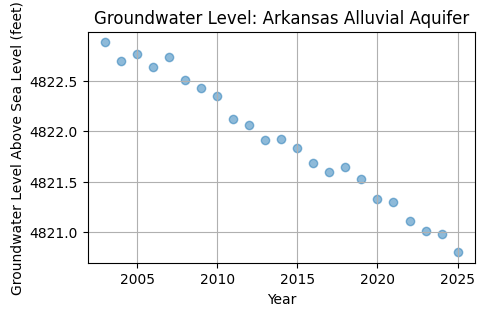

In [ ]:
# plot gw_ark[62611] over gw_ark[YEAR]

plt.figure(figsize=(5, 3))
plt.scatter(gw_ark['YEAR'], gw_ark['62611'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Groundwater Level Above Sea Level (feet)')
plt.title('Groundwater Level: Arkansas Alluvial Aquifer')
plt.grid(True)
plt.savefig('Arkansas_Groundwater.jpeg', dpi=500)
plt.show()

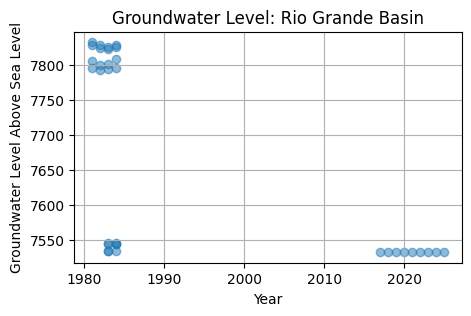

In [ ]:
# plot gw_rio[62611] over gw_rio[YEAR]

plt.figure(figsize=(5, 3))
plt.scatter(gw_rio['YEAR'], gw_rio['62611'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Groundwater Level Above Sea Level')
plt.title('Groundwater Level: Rio Grande Basin')
plt.grid(True)
plt.savefig('Rio_Groundwater.jpeg', dpi=500)
plt.show()

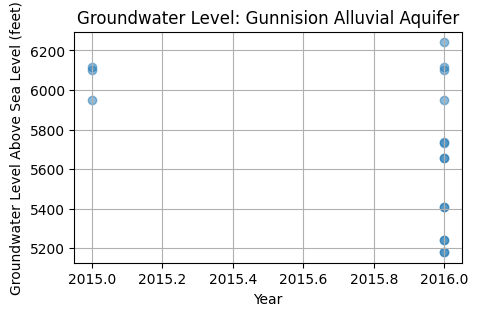

In [ ]:
# plot gw_gunn[62611] over gw_gunn[YEAR]

plt.figure(figsize=(5, 3))
plt.scatter(gw_gunn['YEAR'], gw_gunn['62611'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Groundwater Level Above Sea Level (feet)')
plt.title('Groundwater Level: Gunnision Alluvial Aquifer')
plt.grid(True)
plt.savefig('Gunnison_Groundwater.jpeg', dpi=500)
plt.show()

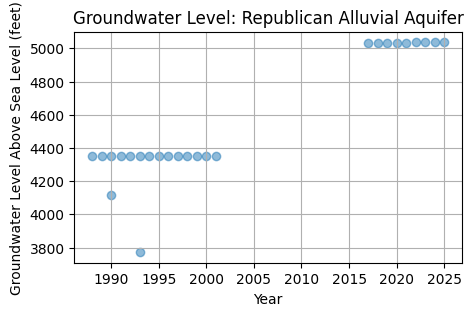

In [ ]:
# plot gw_rep[62611] over gw_rep[YEAR]

plt.figure(figsize=(5, 3))
plt.scatter(gw_rep['YEAR'], gw_rep['62611'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Groundwater Level Above Sea Level (feet)')
plt.title('Groundwater Level: Republican Alluvial Aquifer')
plt.grid(True)
plt.savefig('Republican_Groundwater.jpeg', dpi=500)
plt.show()

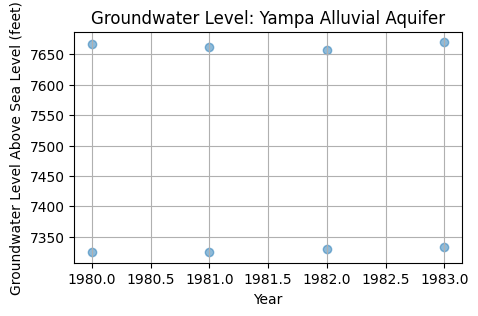

In [ ]:
# plot gw_yam[62611] over gw_yam[YEAR]

plt.figure(figsize=(5, 3))
plt.scatter(gw_yam['YEAR'], gw_yam['62611'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Groundwater Level Above Sea Level (feet)')
plt.title('Groundwater Level: Yampa Alluvial Aquifer')
plt.grid(True)
plt.savefig('Yampa_Groundwater.jpeg', dpi=500)
plt.show()

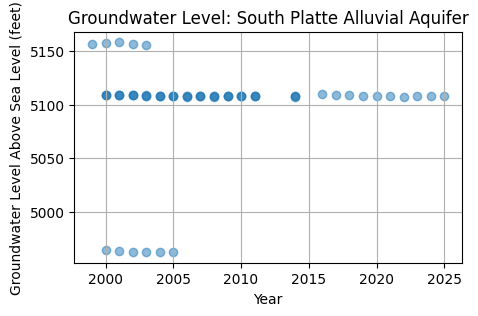

In [ ]:
# plot gw_splatte[62611] over gw_splatte[YEAR]

plt.figure(figsize=(5, 3))
plt.scatter(gw_splatte['YEAR'], gw_splatte['62611'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Groundwater Level Above Sea Level (feet)')
plt.title('Groundwater Level: South Platte Alluvial Aquifer')
plt.grid(True)
plt.savefig('South_Platte_Groundwater.jpeg', dpi=500)
plt.show()

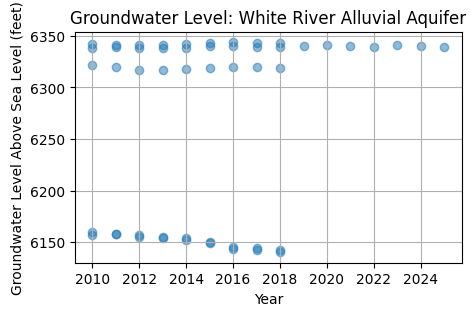

In [ ]:
# plot gw_white[62611] over gw_white[YEAR]

plt.figure(figsize=(5, 3))
plt.scatter(gw_white['YEAR'], gw_white['62611'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Groundwater Level Above Sea Level (feet)')
plt.title('Groundwater Level: White River Alluvial Aquifer')
plt.grid(True)
plt.savefig('White_Groundwater.jpeg', dpi=500)
plt.show()

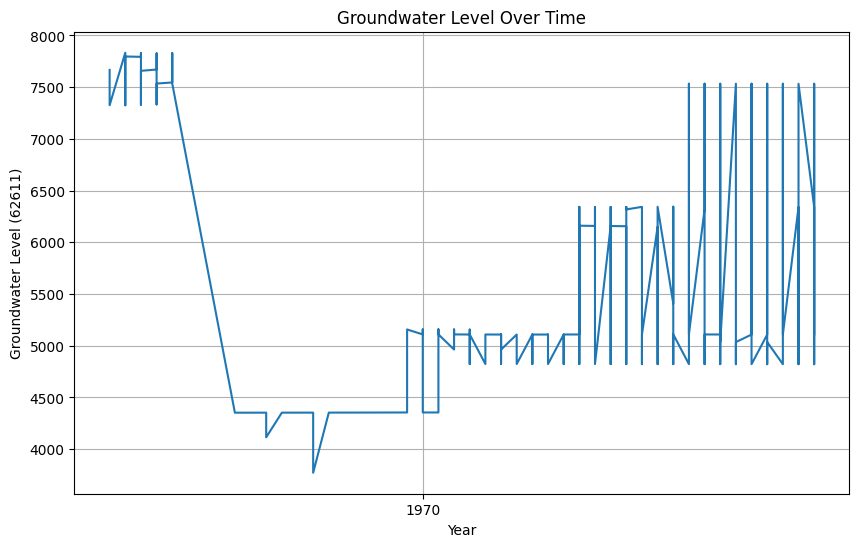

In [ ]:
# plot gw_rio[62611] over years

if 'YEAR' in groundwater.columns:
    groundwater['YEAR'] = pd.to_datetime(groundwater['YEAR'], errors='coerce')

    # Filter the DataFrame to keep only rows where '62611' is not NaN
    plot_data = groundwater.dropna(subset=['62611'])

    # Sort the data by date
    plot_data = plot_data.sort_values(by='YEAR')

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(plot_data['YEAR'], plot_data['62611'])
    plt.xlabel('Year')
    plt.ylabel('Groundwater Level (62611)')
    plt.title('Groundwater Level Over Time')
    plt.grid(True)
    plt.show()
else

In [ ]:
# Perform a spatial join between groundwater wells and aquifers
gw_aq = gpd.sjoin(groundwater_gdf, aquifers, how="inner", predicate="within")
gw_aq = gw_aq.drop(['LAT_DD', 'LONG_DD',], axis=1)
display(gw_aq)
print(gw_aq.dtypes)

,STATION,ELEVATION,WELL_DEPTH,USAQ,LOCALAQ,YEAR,72019,62611,geometry,index_right,River_Basi,AQ_CODE,AQ_NAME
0,372106105241701,7990.0,414.0,NaN,NaN,1981,157.526,7832.474,POINT (-105.40517 37.35172),6,Rio Grande,102,Rio Grande aquifer system
1,372106105241701,7990.0,414.0,NaN,NaN,1982,162.154,7827.846,POINT (-105.40517 37.35172),6,Rio Grande,102,Rio Grande aquifer system
2,372106105241701,7990.0,414.0,NaN,NaN,1983,164.027,7825.973,POINT (-105.40517 37.35172),6,Rio Grande,102,Rio Grande aquifer system
3,372106105241701,7990.0,414.0,NaN,NaN,1984,161.377,7828.623,POINT (-105.40517 37.35172),6,Rio Grande,102,Rio Grande aquifer system
4,372141105281101,7821.0,225.0,NaN,NaN,1981,25.039,7795.961,POINT (-105.47044 37.36156),6,Rio Grande,102,Rio Grande aquifer system
...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,384240108000701,5190.0,22.7,COLORADO PLATEAUS,MANCOS SHALE,2016,9.275,5180.725,POINT (-108.00194 38.71111),3,Gunnison,301,Colorado Plateaus aquifers
214,401518102295701,3900.0,320.0,HIGH PLAINS,OGALLALA FORMATION,1993,128.242,3771.758,POINT (-102.49917 40.255),5,Republican,107,High Plains aquifer
215,374549105540201,7551.0,43.0,NaN,NaN,1983,7.492,7543.508,POINT (-105.90056 37.76361),6,Rio Grande,102,Rio Grande aquifer system
216,374549105540201,7551.0,43.0,NaN,NaN,1984,7.085,7543.915,POINT (-105.90056 37.76361),6,Rio Grande,102,Rio Grande aquifer system


STATION          object
ELEVATION       float64
WELL_DEPTH      float64
USAQ             object
LOCALAQ          object
YEAR              int64
72019           float64
62611           float64
geometry       geometry
index_right       int64
River_Basi       object
AQ_CODE           int32
AQ_NAME          object
dtype: object


In [ ]:
#create a new dataframe to store the mean gw_aq.62611 grouped by gw_aq.YEAR and gw_aq.AQ_NAME
gw_aq_mean = gw_aq.groupby(['YEAR', 'AQ_NAME'])['62611'].mean().reset_index()
# gw_aq['mean_water'] = gw_aq.groupby(['YEAR', 'AQ_NAME'])['62611'].transform('mean')
# gw_aq.head()
gw_aq_mean

,YEAR,AQ_NAME,62611
0,1980,Colorado Plateaus aquifers,7495.91400
1,1981,Colorado Plateaus aquifers,7493.19200
2,1981,Rio Grande aquifer system,7815.65650
3,1982,Colorado Plateaus aquifers,7493.81500
4,1982,Rio Grande aquifer system,7811.23575
...,...,...,...
75,2024,Rio Grande aquifer system,7532.28700
76,2025,Colorado Plateaus aquifers,6339.29100
77,2025,Denver Basin aquifer system,5108.36200
78,2025,High Plains aquifer,5035.62000


In [ ]:
print("Alluvials GeoDataFrame:")
display(alluvials.head())
print("\nAlluvials spatial extent:")
print(alluvials.total_bounds)

print("\nGroundwater GeoDataFrame:")
display(groundwater_gdf.head())
print("\nGroundwater spatial extent:")
print(groundwater_gdf.total_bounds)